In [13]:
from IPython.display import Markdown, display
title = "Torque Analysis"
authors = "Hugo Duchemin"
display(Markdown(f"# {title}"))
display(Markdown(f"by {authors}"))

# Torque Analysis

by Hugo Duchemin

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# We load the data and make a loop to run different participants easier in the future 

In [15]:
sub = '001'
ses = '001'
path = f'/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh'


# The first step is to verify whether the participants followed the protocol correctly

   -0.83047456
0    -0.830475
1    -0.254423
2    -0.350431
3    -0.542449
4    -0.110410


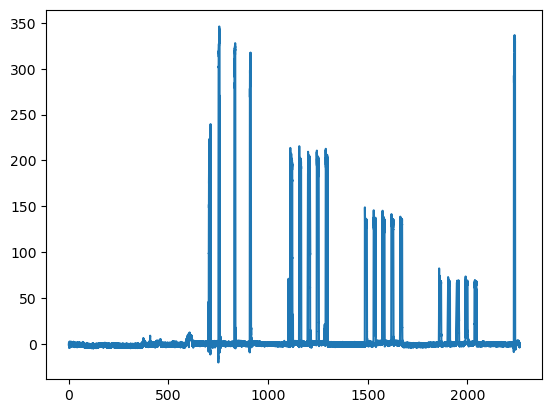

In [16]:
# Load the data from the torque_physio.tsv.gz file
torque_data = pd.read_csv('/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh/sub-001_ses-001_task-isometric_recording-torque_physio.tsv.gz', sep='\t', compression='gzip')
# Display the key information about the data
print (torque_data.head())
# let's plot to see what it looks like
fs = 500  # Sampling frequency in Hz
torque_data['time'] = torque_data.index / fs  # Create a time column based on the index and sampling frequency
plt.plot(torque_data['time'], torque_data.iloc[:, 0])  # Plot the first column of torque data against time


In [17]:
# Load the data events from the events.tsv file
events_data = pd.read_csv('/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh/sub-001_ses-001_task-isometric_recording-torque_events.tsv', sep='\t')
# Display the header of the events data
print("Events Data Columns:", events_data.columns)
print("First 5 Rows of Events Data:\n", events_data.head())

Events Data Columns: Index(['onset', 'duration', 'trial_type'], dtype='object')
First 5 Rows of Events Data:
         onset  duration       trial_type
0   68.895262         0  Occlusion_Start
1  369.112185         0    Occlusion_End
2  633.179443         0     Warmup_Start
3  734.497236         0       Warmup_End
4  747.212569         0  Start_MVC_Pre_1


### Observation : We can see 3 headers (onset, duration and trial type)
- **onset** = precise time of the event (in seconds) 
- **duration** = temporal point (instantanneous) 
- **trial type** = name of the event 

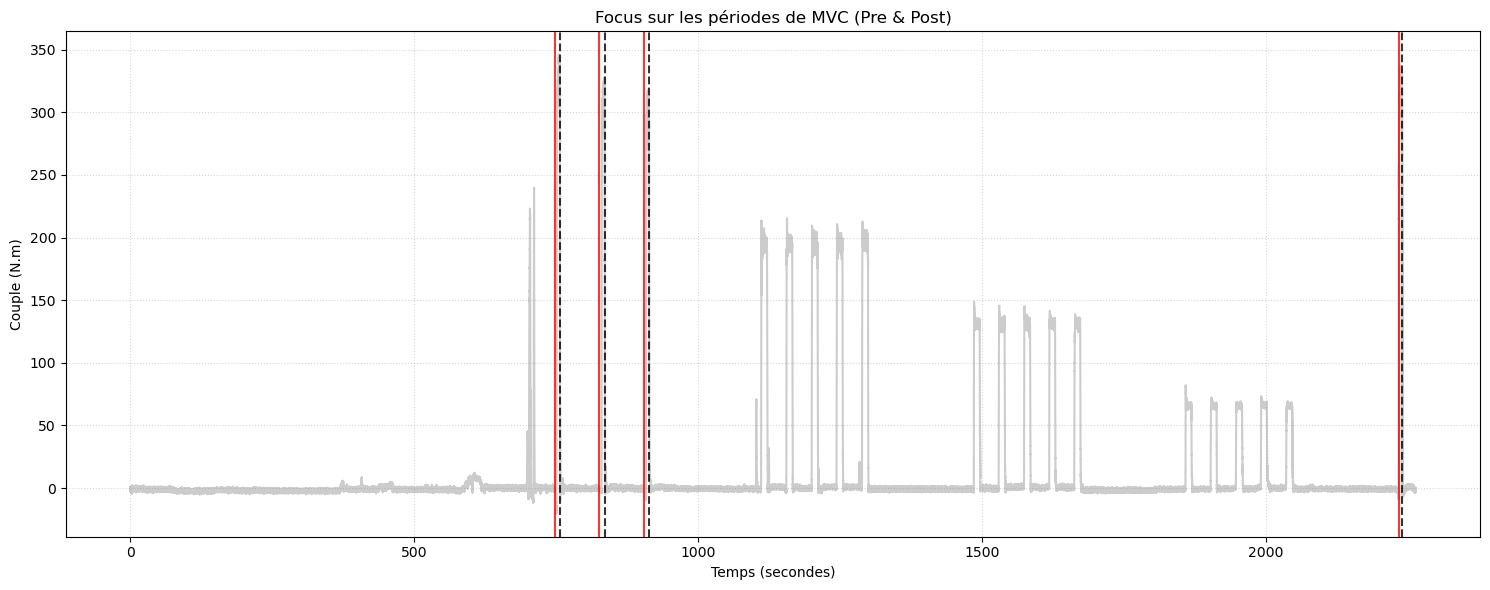

In [18]:
plt.figure(figsize=(15, 6))

# we plot the torque data in gray with some transparency
plt.plot(torque_data['time'], torque_data.iloc[:, 0], label='Torque (N.m)', color='gray', alpha=0.4)

# we iterate through the events data to find the relevant events and plot vertical lines
for index, row in events_data.iterrows():
    name = row['trial_type']
    onset = row['onset']
    
    # we define the conditions for start and stop events based on the trial_type
    is_start = 'Start_MVC' in name
    is_stop = 'Stop_Force' in name or 'Stop_MVC_Post' in name
    
    if is_start or is_stop:
        # color and linestyle for start and stop events
        color = 'red' if is_start else 'black'
        linestyle = '-' if is_start else '--'
        
        # we plot a vertical line at the onset of the event
        plt.axvline(x=onset, color=color, linestyle=linestyle, alpha=0.8)
        
plt.xlabel('Temps (secondes)')
plt.ylabel('Couple (N.m)')
plt.title('Focus sur les périodes de MVC (Pre & Post)')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

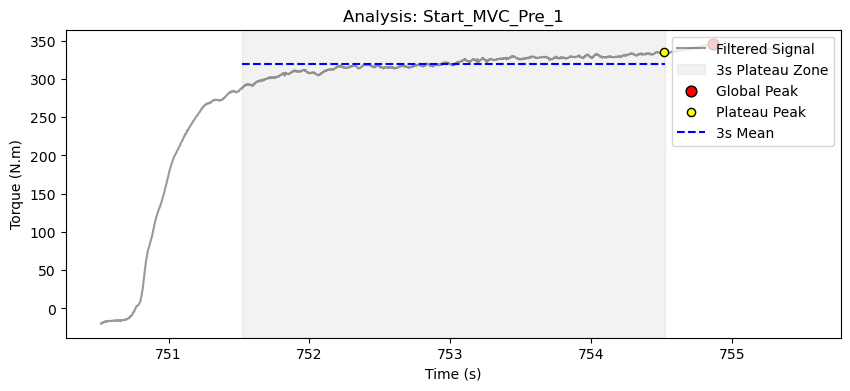

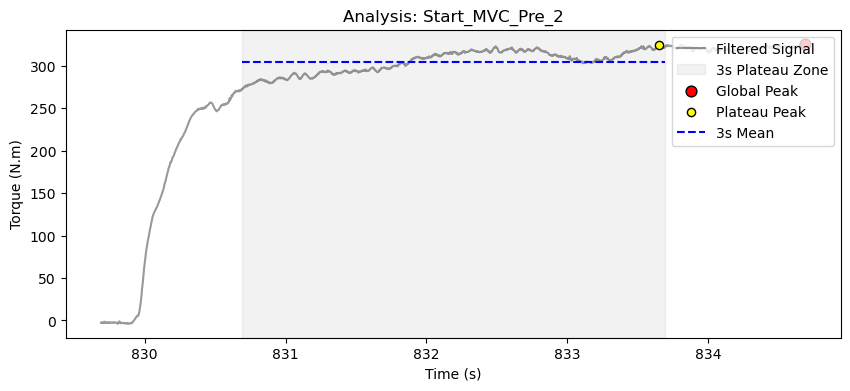

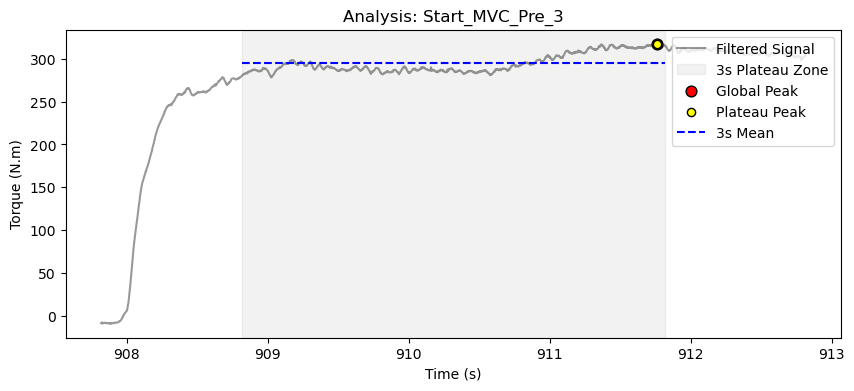

Note: Onset_Force not found for Start_MVC_Post, using event onset instead.


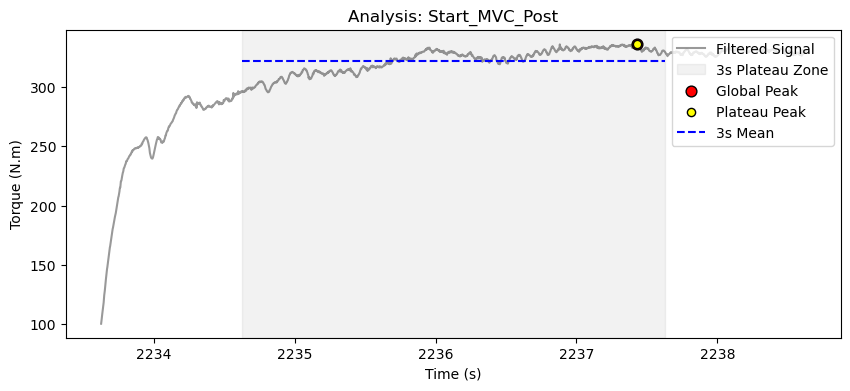


--- Final MVC Summary Table ---
               MVC  Peak_Global  Peak_Plateau_3s     Mean_3s
0  Start_MVC_Pre_1   346.175010       335.702048  319.881332
1  Start_MVC_Pre_2   326.032196       324.866777  304.688520
2  Start_MVC_Pre_3   317.594547       317.594547  294.650166
3   Start_MVC_Post   336.689115       336.689115  322.338201


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- 1. CONFIGURATION AND FILTERING ---
fs = 500  # Sampling frequency
cutoff = 200 # Cut-off frequency for noise reduction

def lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# Apply filter to the torque column (index 0) before analysis
torque_data.iloc[:, 0] = lowpass_filter(torque_data.iloc[:, 0], cutoff, fs)

# --- 2. MVC ANALYSIS ---
mvc_labels = ['Start_MVC_Pre_1', 'Start_MVC_Pre_2', 'Start_MVC_Pre_3', 'Start_MVC_Post']
mvc_results = []

for label in mvc_labels:
    try:
        # 1. Find the start time of the event label
        idx_label = events_data.index[events_data['trial_type'] == label][0]
        t_start_event = events_data.loc[idx_label, 'onset']
        
        # 2. Look for "Onset_Force" occurring AFTER this label
        following_events = events_data.iloc[idx_label:]
        onset_force_list = following_events[following_events['trial_type'] == 'Onset_Force']
        
        if not onset_force_list.empty:
            t_reference = onset_force_list.iloc[0]['onset']
        else:
            # Safety: use event start if Onset_Force is missing (common for Post MVC)
            t_reference = t_start_event
            print(f"Note: Onset_Force not found for {label}, using event onset instead.")

        # 3. Define the 5-second contraction window
        t_end_5s = t_reference + 5
        # Ensure we don't look past the end of the file
        t_end_5s = min(t_end_5s, torque_data['time'].max())
        
        segment_5s = torque_data[(torque_data['time'] >= t_reference) & (torque_data['time'] <= t_end_5s)].copy()
        
        # 4. Define the 3-second plateau window (from T+1s to T+4s)
        t_mean_start = t_reference + 1.0
        t_mean_end = t_reference + 4.0
        
        # Safety: adjust window if the file ends too early
        if t_mean_end > segment_5s['time'].max():
            t_mean_end = segment_5s['time'].max()
            t_mean_start = max(t_reference, t_mean_end - 3.0)

        segment_3s = segment_5s[(segment_5s['time'] >= t_mean_start) & (segment_5s['time'] <= t_mean_end)].copy()
        
        # --- CALCULATIONS ---
        # Global peak over the 5s window (RED DOT)
        peak_5s_val = segment_5s.iloc[:, 0].max()
        peak_5s_time = segment_5s.loc[segment_5s.iloc[:, 0].idxmax(), 'time']
        
        # Plateau peak over the 3s window (YELLOW DOT)
        peak_3s_val = segment_3s.iloc[:, 0].max()
        peak_3s_time = segment_3s.loc[segment_3s.iloc[:, 0].idxmax(), 'time']
        
        # Average torque over the 3s plateau
        mean_3s_val = segment_3s.iloc[:, 0].mean()
        
        mvc_results.append({
            'MVC': label, 
            'Peak_Global': peak_5s_val, 
            'Peak_Plateau_3s': peak_3s_val,
            'Mean_3s': mean_3s_val
        })
        
        # --- VISUALIZATION ---
        plt.figure(figsize=(10, 4))
        plt.plot(segment_5s['time'], segment_5s.iloc[:, 0], color='black', alpha=0.4, label='Filtered Signal')
        
        # Highlight the 3s calculation window
        plt.axvspan(t_mean_start, t_mean_end, color='gray', alpha=0.1, label='3s Plateau Zone')
        
        # Plot markers
        plt.scatter(peak_5s_time, peak_5s_val, color='red', s=60, edgecolors='black', zorder=5, label='Global Peak')
        plt.scatter(peak_3s_time, peak_3s_val, color='yellow', s=35, edgecolors='black', zorder=6, label='Plateau Peak')
        plt.hlines(mean_3s_val, t_mean_start, t_mean_end, colors='blue', linestyles='--', label='3s Mean')
        
        plt.title(f"Analysis: {label}")
        plt.xlabel("Time (s)")
        plt.ylabel("Torque (N.m)")
        plt.legend(loc='upper right')
        plt.show()

    except Exception as e:
        print(f"Error for {label}: {e}")

# --- 3. SUMMARY ---
df_final = pd.DataFrame(mvc_results)
print("\n--- Final MVC Summary Table ---")
print(df_final)

--- FATIGUE ANALYSIS: PRE vs POST ---
Mean of 3 Pre-MVCs  : 306.41 ± 12.70 N.m
Post-MVC Value       : 322.34 N.m
Change (Fatigue)     : 5.20 %
-------------------------------------------
Statistical Results:
t-stat = -2.172 | p-value = 0.1620
=> NON-SIGNIFICANT result (p >= 0.05)


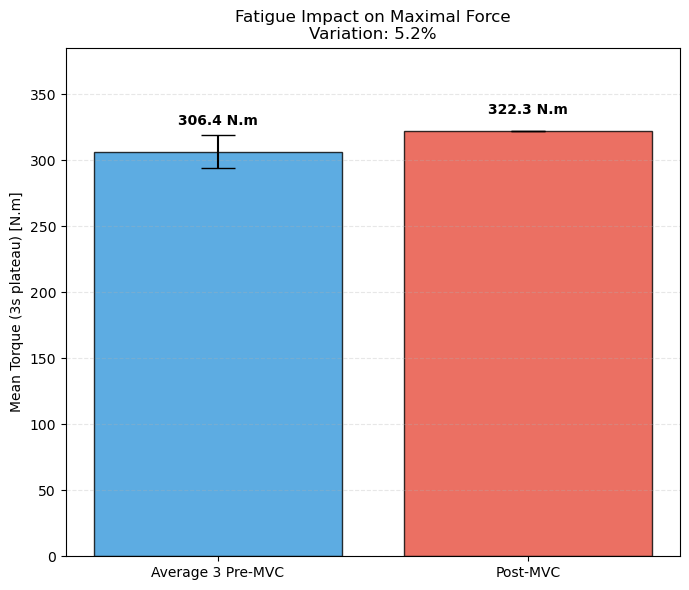

In [20]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# 1. Data extraction
# Separate Pre-test and Post-test data from our summary table
pre_data = df_final[df_final['MVC'].str.contains('Pre')]
post_data = df_final[df_final['MVC'].str.contains('Post')]

# Check if we have the required number of trials (3 Pre, 1 Post)
if len(pre_data) == 3 and len(post_data) == 1:
    pre_means = pre_data['Mean_3s'].values
    post_mean = post_data['Mean_3s'].values[0]

    # 2. Calculate Mean and Standard Deviation for Pre MVCs
    group_pre_avg = np.mean(pre_means)
    group_pre_std = np.std(pre_means, ddof=1) # ddof=1 for sample standard deviation

    # 3. Calculate Fatigue Index (Percentage change of fatigue)
    percentage_change = ((post_mean - group_pre_avg) / group_pre_avg) * 100

    # 4. Statistical Test (One-sample t-test)
    # Compare if the Post value is significantly different from the Pre-test
    t_stat, p_val = stats.ttest_1samp(pre_means, post_mean)

    # PRINT RESULTS
    print(f"--- FATIGUE ANALYSIS: PRE vs POST ---")
    print(f"Mean of 3 Pre-MVCs  : {group_pre_avg:.2f} ± {group_pre_std:.2f} N.m")
    print(f"Post-MVC Value       : {post_mean:.2f} N.m")
    print(f"Change (Fatigue)     : {percentage_change:.2f} %")
    print(f"-------------------------------------------")
    print(f"Statistical Results:")
    print(f"t-stat = {t_stat:.3f} | p-value = {p_val:.4f}")

    if p_val < 0.05:
        print("=> SIGNIFICANT result (p < 0.05)")
    else:
        print("=> NON-SIGNIFICANT result (p >= 0.05)")

    # VISUALIZATION
    plt.figure(figsize=(7, 6))
    
    labels = ['Average 3 Pre-MVC', 'Post-MVC']
    values = [group_pre_avg, post_mean]
    errors = [group_pre_std, 0] # No error bar for a single measurement (Post)

    bars = plt.bar(labels, values, yerr=errors, capsize=12, 
                   color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.8)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (group_pre_std if height == group_pre_avg else 5) + 5,
                 f'{height:.1f} N.m', ha='center', va='bottom', fontweight='bold')

    plt.ylabel('Mean Torque (3s plateau) [N.m]')
    plt.title(f'Fatigue Impact on Maximal Force\nVariation: {percentage_change:.1f}%')
    plt.ylim(0, max(values) + group_pre_std + 50) # Adjust Y-axis scale
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:
    print("Error: df_final must contain exactly 3 'Pre' trials and 1 'Post' trial.")
    print(f"Current count: {len(pre_data)} Pre, {len(post_data)} Post.")

## Now that we have the pipeline for one participant, the objective is too create a loop to observe if the protocol has been correctly runned on every participant and we don't have any fatigue 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy import stats
import os

# --- 1. CONFIGURATION ---
subjects = ['sub-001', 'sub-002', 'sub-003']
sessions = ['ses-001', 'ses-002']
fs = 500  
cutoff = 200 
mvc_labels = ['Start_MVC_Pre_1', 'Start_MVC_Pre_2', 'Start_MVC_Pre_3', 'Start_MVC_Post']

# Root path
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'

def lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# List to store results of all 6 sessions
global_results = []

# --- 2. NESTED LOOP (Subjects & Sessions) ---
for sub_id in subjects:
    for ses_id in sessions:
        print(f"Checking Fatigue: {sub_id} | {ses_id}...")
        
        # Path construction
        beh_folder = f"{base_dir}/{sub_id}/{ses_id}/beh"
        torque_path = f"{beh_folder}/{sub_id}_{ses_id}_task-isometric_recording-torque_physio.tsv.gz"
        events_path = f"{beh_folder}/{sub_id}_{ses_id}_task-isometric_recording-torque_events.tsv"

        # Check if files exist before processing
        if not os.path.exists(torque_path):
            print(f"Skipping: File not found for {sub_id} {ses_id}")
            continue

        try:
            # Load Data
            torque_data = pd.read_csv(torque_path, sep='\t', compression='gzip')
            events_data = pd.read_csv(events_path, sep='\t')
            torque_data['time'] = np.arange(len(torque_data)) / fs
            
            # Filter
            torque_data.iloc[:, 0] = lowpass_filter(torque_data.iloc[:, 0], cutoff, fs)

            session_mvc_list = []
            
            # Analyze each MVC in the session
            for label in mvc_labels:
                idx = events_data.index[events_data['trial_type'] == label][0]
                t_event_start = events_data.loc[idx, 'onset']
                
                following = events_data.iloc[idx:]
                onset_list = following[following['trial_type'] == 'Onset_Force']
                t_ref = onset_list.iloc[0]['onset'] if not onset_list.empty else t_event_start
                
                # Windows
                t_mean_start, t_mean_end = t_ref + 1.0, t_ref + 4.0
                
                # Metrics (Mean on 3s plateau)
                seg_3s = torque_data[(torque_data['time'] >= t_mean_start) & (torque_data['time'] <= t_mean_end)]
                mean_val = seg_3s.iloc[:, 0].mean()
                
                session_mvc_list.append(mean_val)

            # --- 3. FATIGUE CALCULATION FOR THIS SESSION ---
            pre_means = session_mvc_list[0:3] # The 3 Pre
            post_mean = session_mvc_list[3]   # The Post
            
            avg_pre = np.mean(pre_means)
            fatigue_index = ((post_mean - avg_pre) / avg_pre) * 100
            
            # Statistical test (p-value)
            _, p_val = stats.ttest_1samp(pre_means, post_mean)
            
            # Save results
            global_results.append({
                'Subject': sub_id,
                'Session': ses_id,
                'Pre_Mean_Avg': avg_pre,
                'Post_Mean': post_mean,
                'Fatigue_Index_%': round(fatigue_index, 2),
                'P_Value': round(p_val, 4),
                'Valid': 'Yes' if p_val > 0.05 else 'NO (Fatigued)'
            })

        except Exception as e:
            print(f"Error processing {sub_id} {ses_id}: {e}")

# --- 4. FINAL VALIDATION TABLE ---
summary_df = pd.DataFrame(global_results)
print("\n--- GLOBAL VALIDATION SUMMARY ---")
print(summary_df)

# Check if any session failed
failed_sessions = summary_df[summary_df['Valid'] == 'NO (Fatigued)']
if not failed_sessions.empty:
    print("\nWARNING: Some sessions show significant fatigue!")
    print(failed_sessions)
else:
    print("\nSUCCESS: All sessions are valid (no significant fatigue).")

Checking Fatigue: sub-001 | ses-001...
Checking Fatigue: sub-001 | ses-002...
Checking Fatigue: sub-002 | ses-001...
Checking Fatigue: sub-002 | ses-002...
Checking Fatigue: sub-003 | ses-001...
Checking Fatigue: sub-003 | ses-002...

--- GLOBAL VALIDATION SUMMARY ---
   Subject  Session  Pre_Mean_Avg   Post_Mean  Fatigue_Index_%  P_Value  \
0  sub-001  ses-001    306.406673  322.338201             5.20   0.1620   
1  sub-001  ses-002    298.464910  354.526808            18.78   0.0666   
2  sub-002  ses-001    179.955636  159.095936           -11.59   0.3104   
3  sub-002  ses-002    275.322650  260.805856            -5.27   0.2090   
4  sub-003  ses-001    290.004654  321.539627            10.87   0.0628   
5  sub-003  ses-002    340.723341  309.182053            -9.26   0.0240   

           Valid  
0            Yes  
1            Yes  
2            Yes  
3            Yes  
4            Yes  
5  NO (Fatigued)  

   Subject  Session  Pre_Mean_Avg   Post_Mean  Fatigue_Index_%  P_Value

### We can see with our loop that the participant 3, during the second session show wignificant fatigue. We will plot his torque signal to check. 

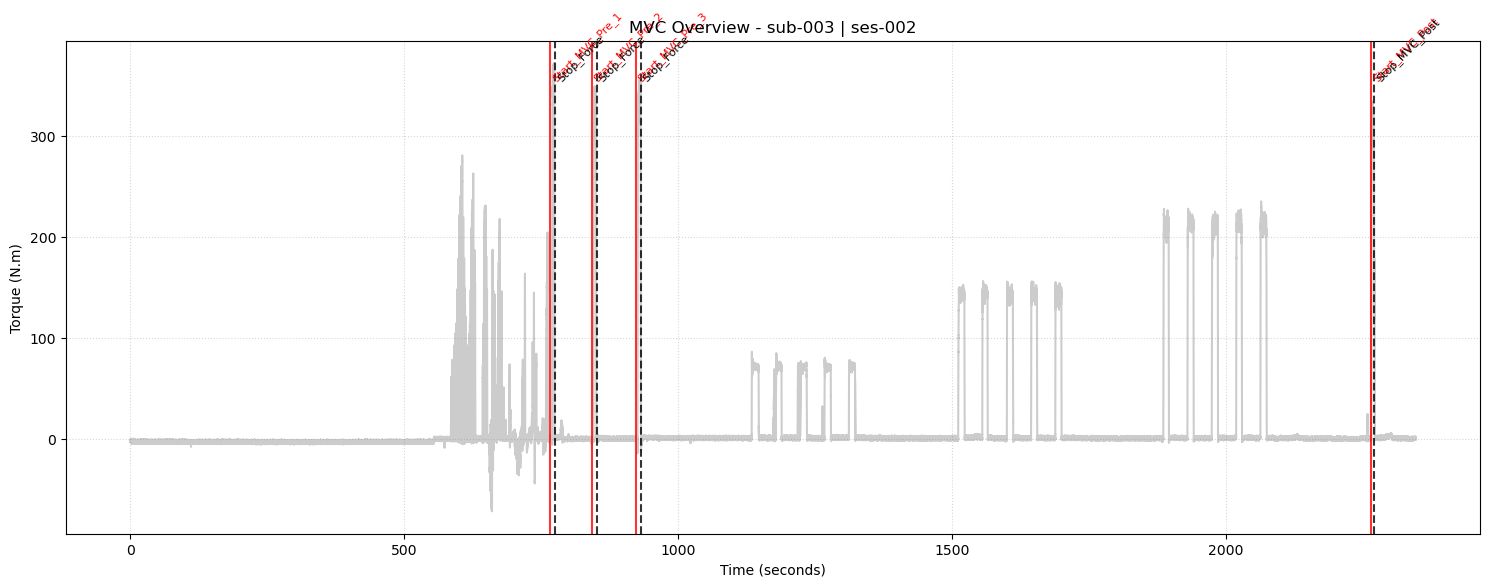

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# --- 1. SETTINGS FOR SUB-003 SES-002 ---
sub_id = 'sub-003'
ses_id = 'ses-002'
fs = 500
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'
beh_folder = f"{base_dir}/{sub_id}/{ses_id}/beh"

# Auto-detect the files for this specific session
torque_files = glob.glob(f"{beh_folder}/*torque_physio.tsv.gz")
events_files = glob.glob(f"{beh_folder}/*events.tsv")

if torque_files and events_files:
    # Load Data
    torque_data = pd.read_csv(torque_files[0], sep='\t', compression='gzip')
    events_data = pd.read_csv(events_files[0], sep='\t')
    torque_data['time'] = np.arange(len(torque_data)) / fs

    # --- 2. PLOTTING ---
    plt.figure(figsize=(15, 6))

    # Plot the torque signal
    plt.plot(torque_data['time'], torque_data.iloc[:, 0], label='Torque (N.m)', color='gray', alpha=0.4)

    # Plot event markers
    for index, row in events_data.iterrows():
        name = row['trial_type']
        onset = row['onset']
        
        # Check for MVC starts and any stops
        is_start = 'Start_MVC' in name
        is_stop = 'Stop_Force' in name or 'Stop_MVC_Post' in name
        
        if is_start or is_stop:
            color = 'red' if is_start else 'black'
            linestyle = '-' if is_start else '--'
            
            plt.axvline(x=onset, color=color, linestyle=linestyle, alpha=0.8)
            # Add text label for clarity
            plt.text(onset, plt.ylim()[1]*0.9, name, rotation=45, color=color, fontsize=8)

    plt.xlabel('Time (seconds)')
    plt.ylabel('Torque (N.m)')
    plt.title(f'MVC Overview - {sub_id} | {ses_id}')
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print(f"Error: Could not find files for {sub_id} in {ses_id}")

In [23]:
# --- 1. SETTINGS FOR ANALYSIS ---
# (Assumes torque_data and events_data are already loaded for Sub-003, Ses-002)
mvc_labels = ['Start_MVC_Pre_1', 'Start_MVC_Pre_2', 'Start_MVC_Pre_3', 'Start_MVC_Post']
session_results = []

# --- 2. CALCULATE METRICS ---
for label in mvc_labels:
    try:
        # Find the event onset
        idx = events_data.index[events_data['trial_type'] == label][0]
        t_start = events_data.loc[idx, 'onset']
        
        # Check for Onset_Force or use start time
        following = events_data.iloc[idx:]
        onset_list = following[following['trial_type'] == 'Onset_Force']
        t_ref = onset_list.iloc[0]['onset'] if not onset_list.empty else t_start
        
        # Define 5s window for peak and 3s for mean (plateau)
        t_end_5s = min(t_ref + 5, torque_data['time'].max())
        t_mean_start, t_mean_end = t_ref + 1.0, t_ref + 4.0
        
        # Extract segments
        seg_5s = torque_data[(torque_data['time'] >= t_ref) & (torque_data['time'] <= t_end_5s)]
        seg_3s = torque_data[(torque_data['time'] >= t_mean_start) & (torque_data['time'] <= t_mean_end)]
        
        # Calculations
        peak_global = seg_5s.iloc[:, 0].max()
        mean_plateau = seg_3s.iloc[:, 0].mean()
        
        session_results.append({
            'MVC Label': label,
            'Global Peak (N.m)': round(peak_global, 2),
            'Plateau Mean (N.m)': round(mean_plateau, 2)
        })
    except Exception as e:
        print(f"Skipping {label}: {e}")

# --- 3. PRINT THE TABLE ---
df_sub3_ses2 = pd.DataFrame(session_results)

print(f"\n--- MVC RESULTS FOR {sub_id} | {ses_id} ---")
print(df_sub3_ses2.to_string(index=False))

# Calculate the Fatigue Index just for this session
if len(session_results) == 4:
    pre_avg = df_sub3_ses2.iloc[0:3, 2].mean() # Average of Plateau Mean for Pre
    post_val = df_sub3_ses2.iloc[3, 2]         # Plateau Mean for Post
    fatigue = ((post_val - pre_avg) / pre_avg) * 100
    print(f"\nFatigue Index: {fatigue:.2f}%")


--- MVC RESULTS FOR sub-003 | ses-002 ---
      MVC Label  Global Peak (N.m)  Plateau Mean (N.m)
Start_MVC_Pre_1             372.24              350.60
Start_MVC_Pre_2             349.30              334.71
Start_MVC_Pre_3             355.88              336.87
 Start_MVC_Post             334.23              309.18

Fatigue Index: -9.26%


### Now we want to plot with bars all the participant and all the sessions to visualize the difference

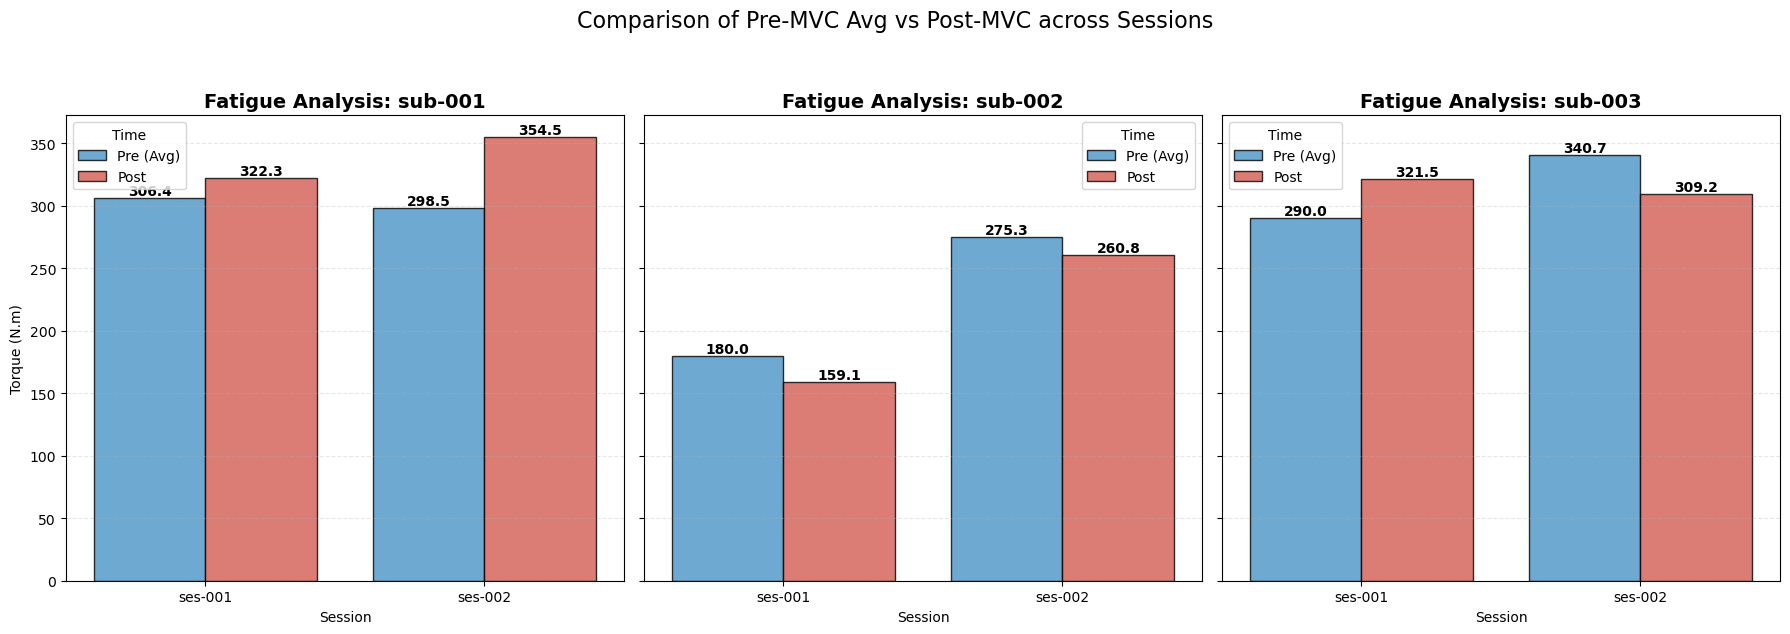

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. RESHAPE DATA FOR PLOTTING ---
# We need to transform the data to have 'Condition' (Pre vs Post) as a column
plot_list = []
for _, row in summary_df.iterrows():
    # Add Pre-average entry
    plot_list.append({
        'Subject': row['Subject'],
        'Session': row['Session'],
        'Time': 'Pre (Avg)',
        'Torque': row['Pre_Mean_Avg']
    })
    # Add Post entry
    plot_list.append({
        'Subject': row['Subject'],
        'Session': row['Session'],
        'Time': 'Post',
        'Torque': row['Post_Mean']
    })

df_plot = pd.DataFrame(plot_list)

# --- 2. CREATE SUBPLOTS ---
# We create 1 row of 3 plots (one for each subject)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
subjects = df_plot['Subject'].unique()

for i, sub in enumerate(subjects):
    sub_data = df_plot[df_plot['Subject'] == sub]
    
    # Create the grouped bar chart for this specific subject
    sns.barplot(ax=axes[i], data=sub_data, x='Session', y='Torque', hue='Time',
                palette=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.8)
    
    # Titles and Labels
    axes[i].set_title(f'Fatigue Analysis: {sub}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Torque (N.m)' if i == 0 else '')
    axes[i].set_xlabel('Session')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add values on top of bars
    for p in axes[i].patches:
        if p.get_height() > 0:
            axes[i].annotate(f'{p.get_height():.1f}', 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparison of Pre-MVC Avg vs Post-MVC across Sessions', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### **Observation** : We can observe on this comparison between the 3 participants and the two sessions/participant that during his second session, the third participant show some fatigue (-9.26%). Given our small sub-sample size (n=3) relative to the total sample (n=20) in our "real study", we anticipate that this level of fatigue will become non-significant once the full analysis is conducted.